In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To display plots properly
%matplotlib inline


In [32]:
df=pd.read_csv("Dataset.csv")

In [12]:
##Creating Age Bands

def age_band(age):
    
    if age <= 9:
        return "Child"  ##5-9 as "Child"
    elif age <= 13:
        return "Pre-Teen" ##10-13 as "Pre-Teen"
    elif age <= 16:
        return "Teen"  ##14-16 as "Teen"
    elif age<=18:
        return "Senior Teen"  ## 17-18 as "Senior Teen"
    else:
        return "Out of Range" ## incase of Outliers

df["Age_Band"] = df["Age"].apply(age_band)

def screen_time_category(hours):
    if hours <= 2:
        return "Low"
    elif hours <= 4:
        return "Moderate"
    elif hours <= 6:
        return "High"
    else:
        return "Very High"

df["Screen_Time_Category"] = df["Avg_Daily_Screen_Time_hr"].apply(screen_time_category)


def device_type_category(device):
    if device in ["Smartphone", "Tablet", "Laptop"]:
        return "Portable"
    elif device in ["Desktop", "Smart TV"]:
        return "Wall-Mounted"
    else:
        return "Other"

df["Device_Type_Category"] = df["Primary_Device"].apply(device_type_category)


def usage_balance_category(ratio):
    if ratio < 0.5:
        return "Mostly Recreational"
    elif 0.5 <= ratio <= 1:
        return "Balanced"
    else:
        return "Mostly Educational"

df["Usage_Balance_Category"] = df["Educational_to_Recreational_Ratio"].apply(usage_balance_category)


def health_risk_level(impact):
    if impact == "None":
        return "No Risk"
    
    issues = impact.split(",")
    
    if len(issues) == 1:
        return "Moderate Risk"
    else:
        return "High Risk"

df["Health_Risk_Level"] = df["Health_Impacts"].apply(health_risk_level)


def calculate_edu_time(row):
    ratio = row["Educational_to_Recreational_Ratio"]
    total = row["Avg_Daily_Screen_Time_hr"]
    
    return (ratio * total) / (1 + ratio)

df["Educational_Time_hr"] = df.apply(calculate_edu_time, axis=1)
df["Educational_Time_hr"] = df["Educational_Time_hr"].round(3)


def calculate_rec_time(row):
    ratio = row["Educational_to_Recreational_Ratio"]
    total = row["Avg_Daily_Screen_Time_hr"]
    
    return total / (1 + ratio)

def convert_to_actual_time(decimal_hours):
    hours = int(decimal_hours)
    minutes = round((decimal_hours - hours) * 60)
    return f"{hours} hr {minutes} min"

df["Educational_Time_Actual"] = df["Educational_Time_hr"].apply(convert_to_actual_time)
df["Recreational_Time_Actual"] = df["Recreational_Time_hr"].apply(convert_to_actual_time)

df[["Educational_Time_hr", "Educational_Time_Actual",
    "Recreational_Time_hr", "Recreational_Time_Actual"]].head()
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,Screen_Time_Category,Device_Type_Category,Usage_Balance_Category,Health_Risk_Level,Educational_Time_hr,Recreational_Time_hr,Educational_Time_Actual,Recreational_Time_Actual
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,Teen,Moderate,Portable,Mostly Recreational,High Risk,1.180,2.810,1 hr 11 min,2 hr 49 min
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,Pre-Teen,High,Portable,Mostly Recreational,Moderate Risk,1.064,3.546,1 hr 4 min,3 hr 33 min
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,Senior Teen,Moderate,Other,Mostly Recreational,Moderate Risk,0.904,2.826,0 hr 54 min,2 hr 50 min
3,15,Female,1.21,Laptop,False,0.39,None,Urban,Teen,Low,Portable,Mostly Recreational,No Risk,0.339,0.871,0 hr 20 min,0 hr 52 min
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,Pre-Teen,High,Portable,Mostly Recreational,High Risk,1.937,3.953,1 hr 56 min,3 hr 57 min
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban,Senior Teen,Moderate,Portable,Mostly Recreational,Moderate Risk,0.996,2.264,0 hr 60 min,2 hr 16 min
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural,Senior Teen,High,Portable,Mostly Recreational,Moderate Risk,1.266,3.164,1 hr 16 min,3 hr 10 min
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,Teen,High,Portable,Mostly Recreational,High Risk,1.577,4.043,1 hr 35 min,4 hr 3 min
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban,Senior Teen,High,Other,Mostly Recreational,Moderate Risk,1.684,3.916,1 hr 41 min,3 hr 55 min


Numerical Columns: ['Age', 'Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio', 'Educational_Time_hr', 'Recreational_Time_hr']

Univariate Analysis for: Age


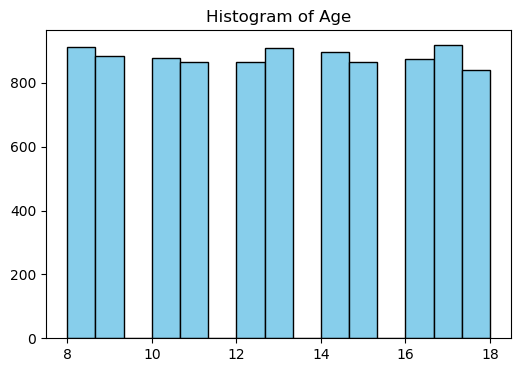

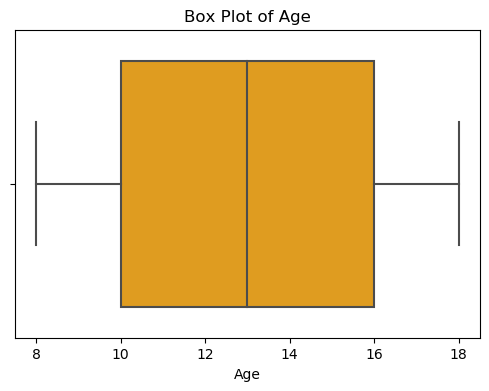

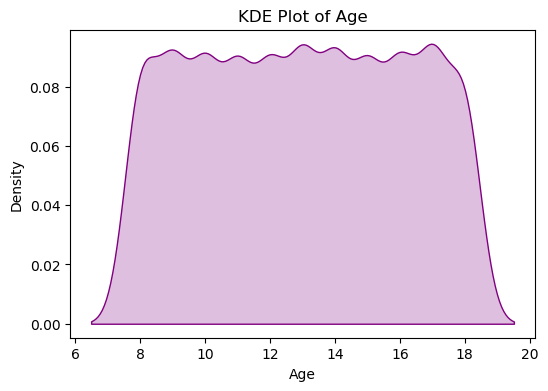

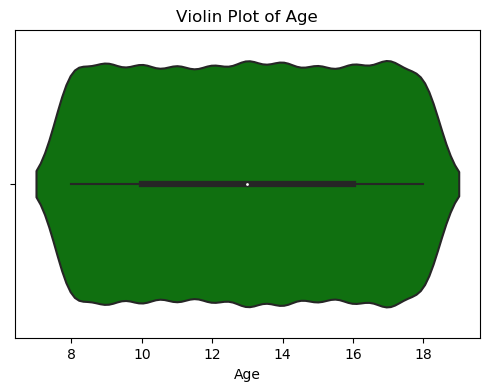

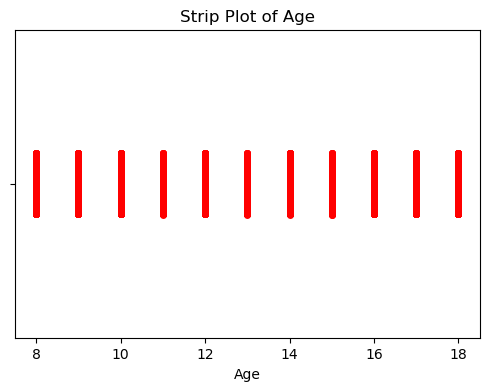


Univariate Analysis for: Avg_Daily_Screen_Time_hr


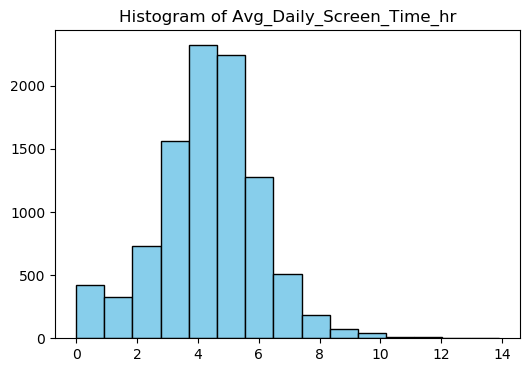

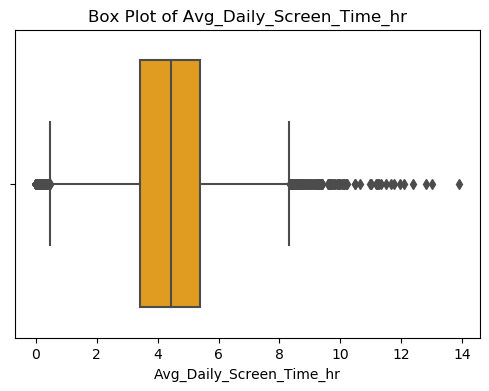

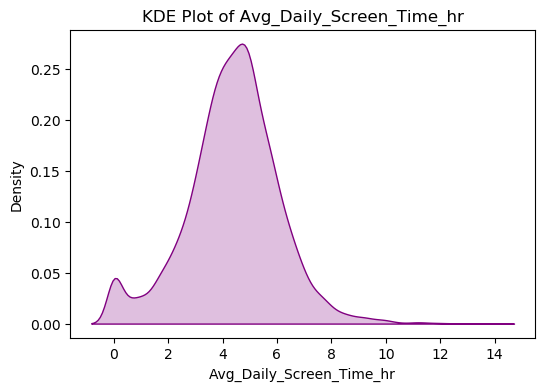

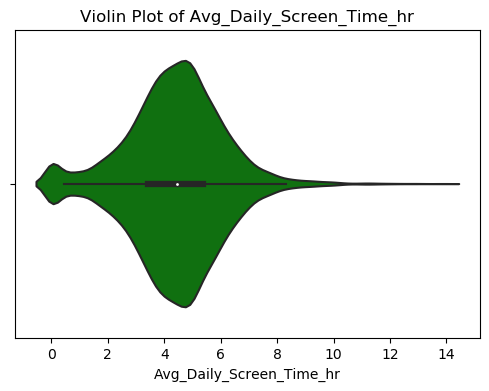

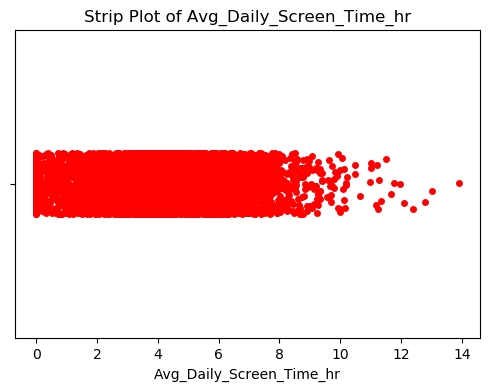


Univariate Analysis for: Educational_to_Recreational_Ratio


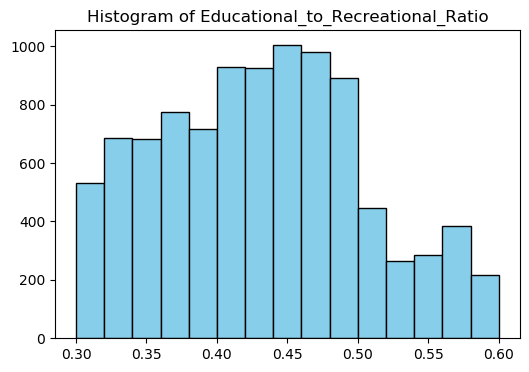

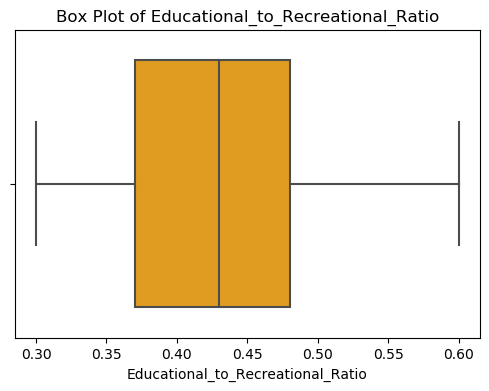

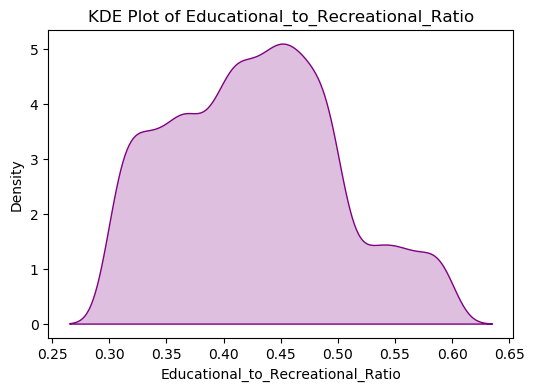

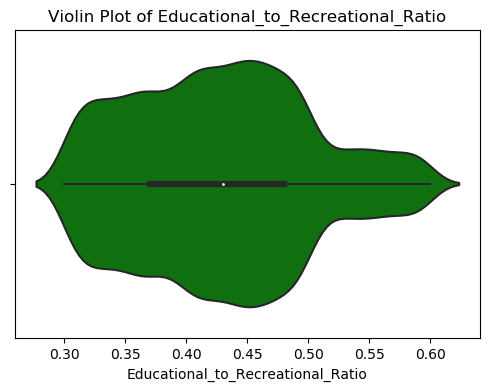

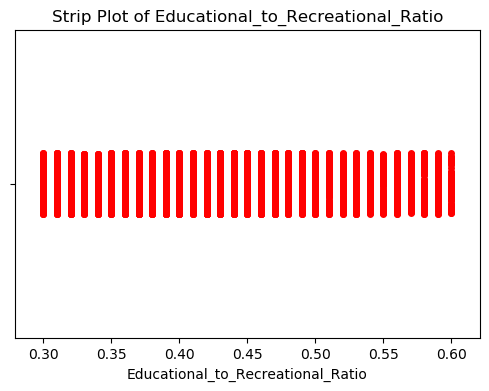


Univariate Analysis for: Educational_Time_hr


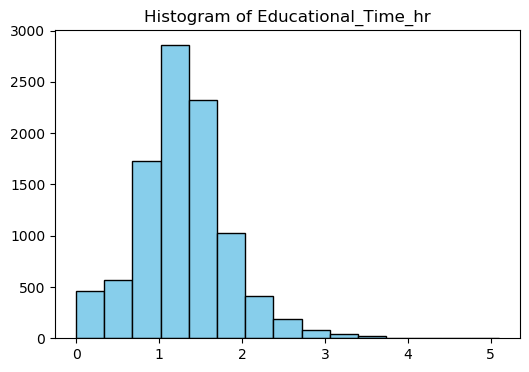

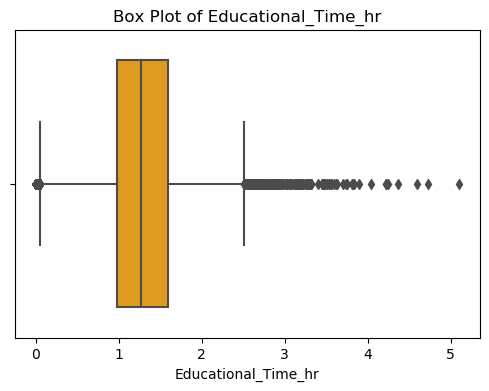

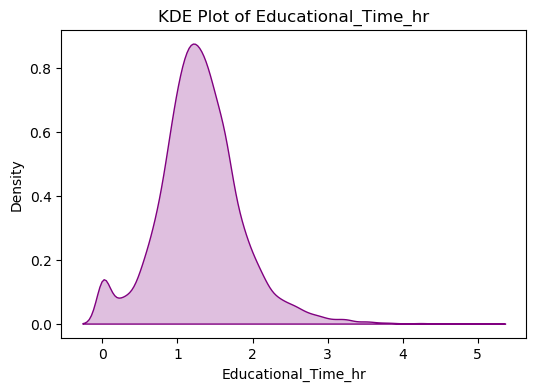

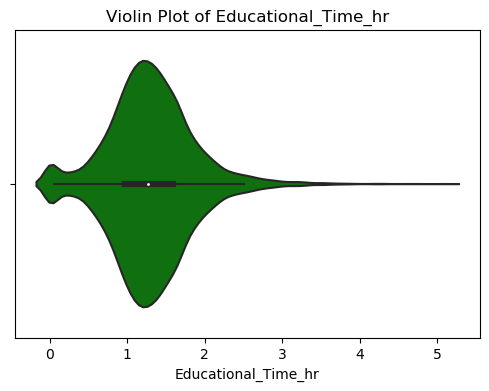

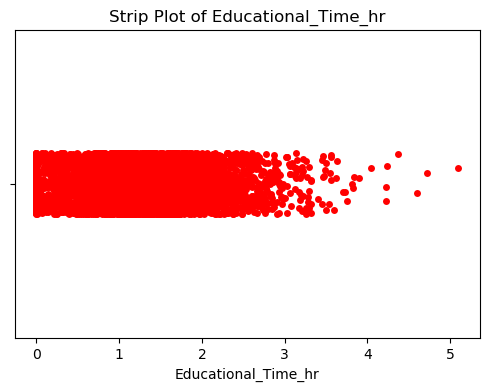


Univariate Analysis for: Recreational_Time_hr


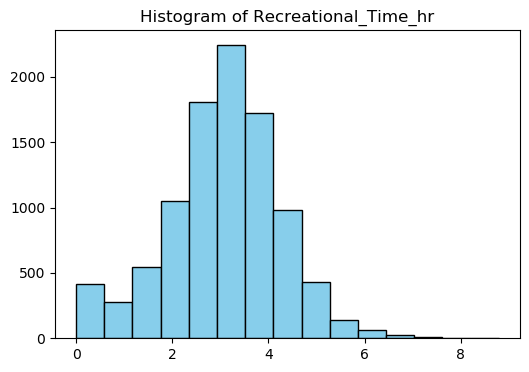

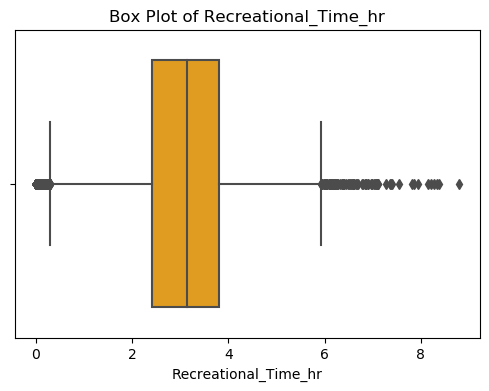

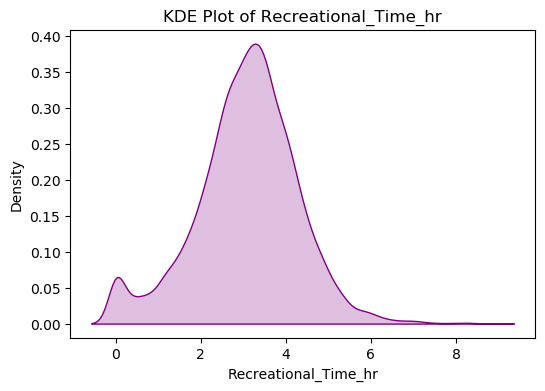

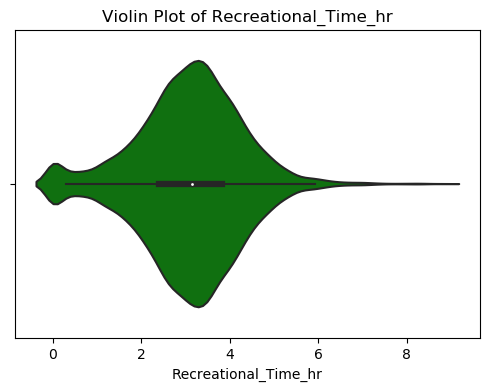

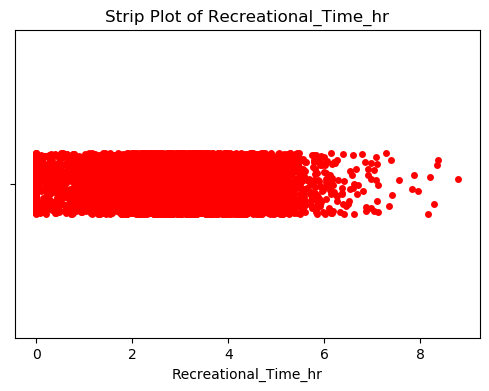

In [13]:
# Manually detect numeric columns
num_cols = []

for col in df.columns:
    if df[col].dtype == 'int64' or df[col].dtype == 'float64':
        num_cols.append(col)

print("Numerical Columns:", num_cols)

for col in num_cols:
    
    print(f"\nUnivariate Analysis for: {col}")
    
    # Histogram
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=15, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.show()
    
    # Box Plot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Box Plot of {col}')
    plt.show()
    
    # KDE
    plt.figure(figsize=(6,4))
    sns.kdeplot(df[col], fill=True, color='purple')
    plt.title(f'KDE Plot of {col}')
    plt.show()
    
    # Violin
    plt.figure(figsize=(6,4))
    sns.violinplot(x=df[col], color='green')
    plt.title(f'Violin Plot of {col}')
    plt.show()
    
    # Strip
    plt.figure(figsize=(6,4))
    sns.stripplot(x=df[col], color='red')
    plt.title(f'Strip Plot of {col}')
    plt.show()


Univariate Analysis for: Gender


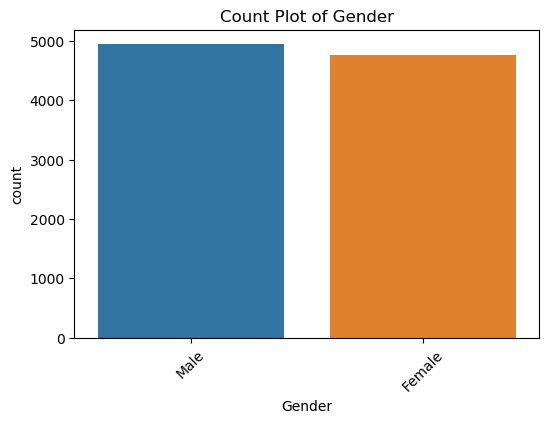

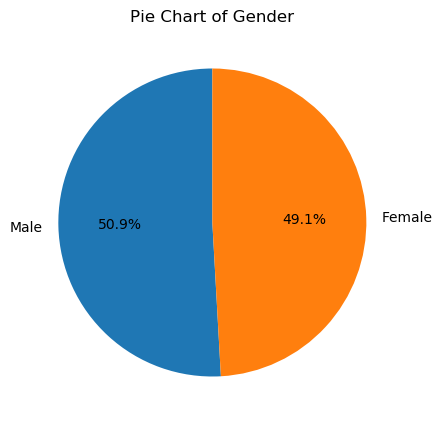

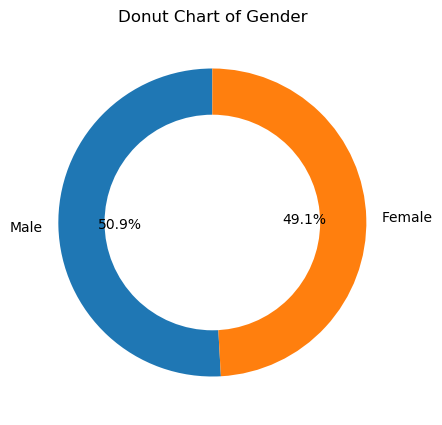


Univariate Analysis for: Primary_Device


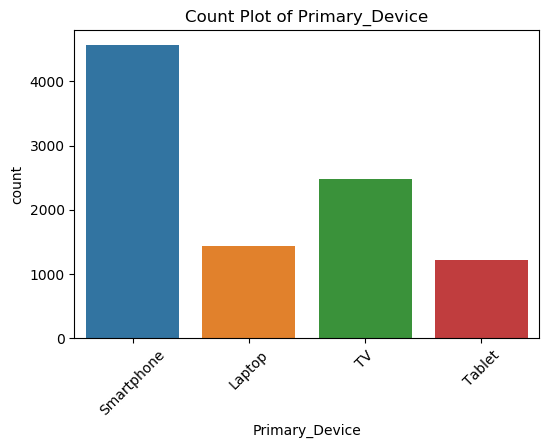

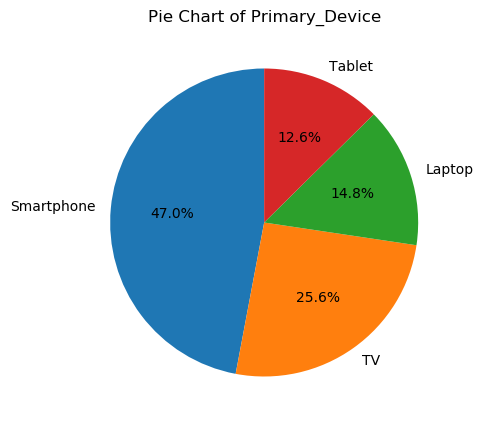

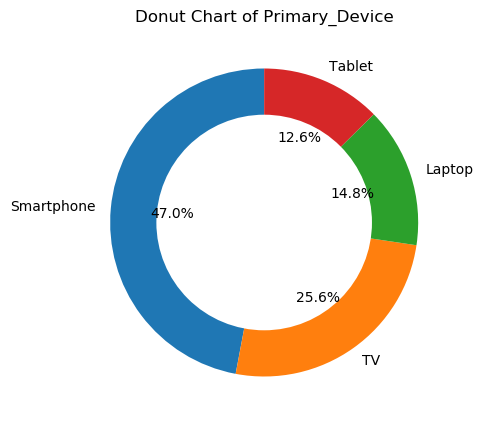


Univariate Analysis for: Exceeded_Recommended_Limit


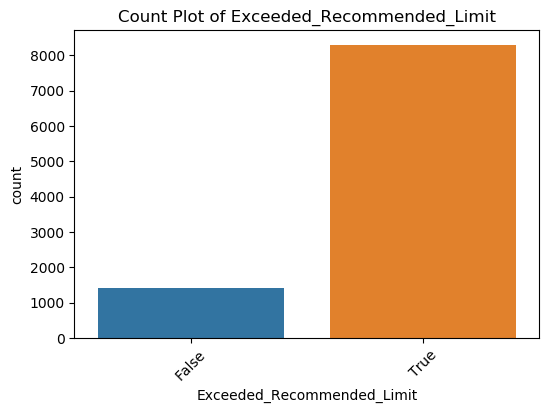

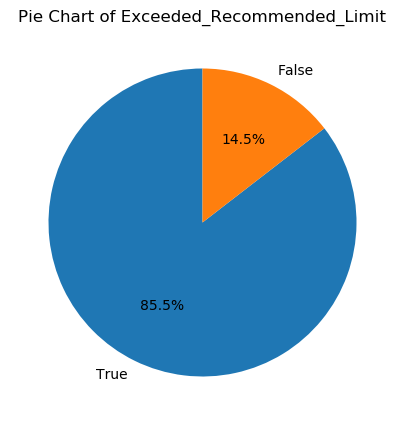

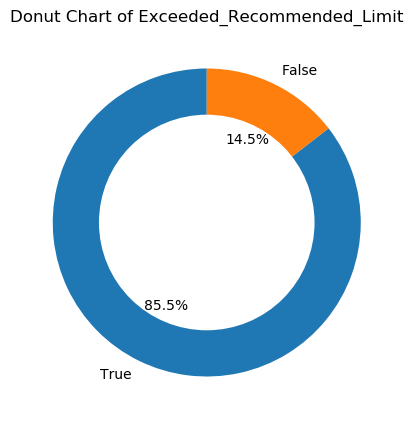


Univariate Analysis for: Urban_or_Rural


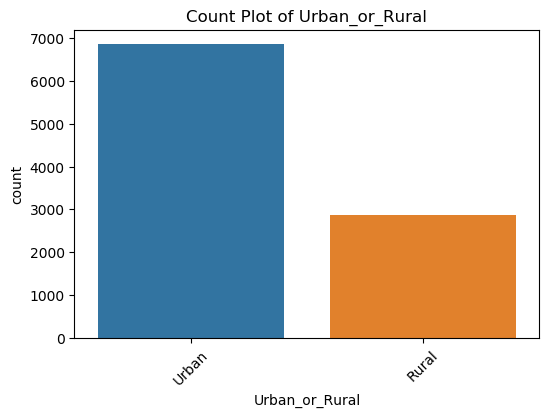

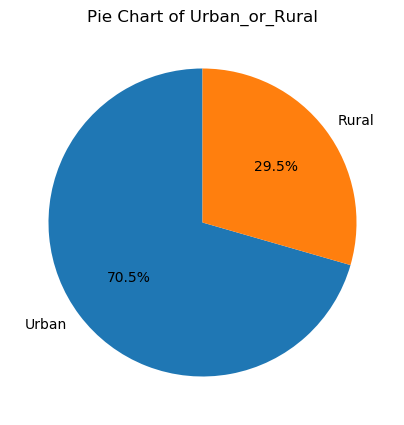

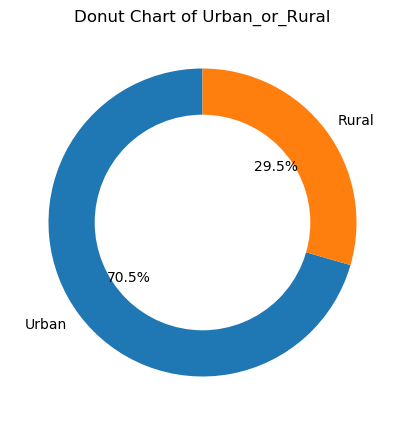


Univariate Analysis for: Age_Band


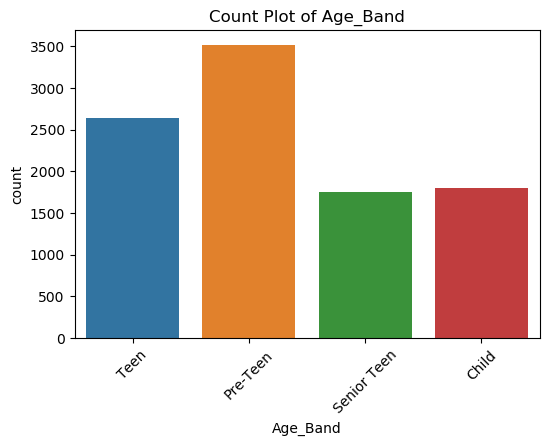

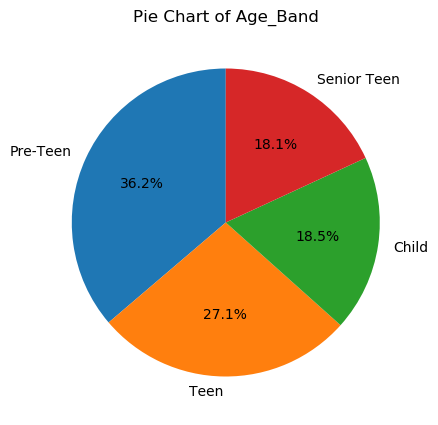

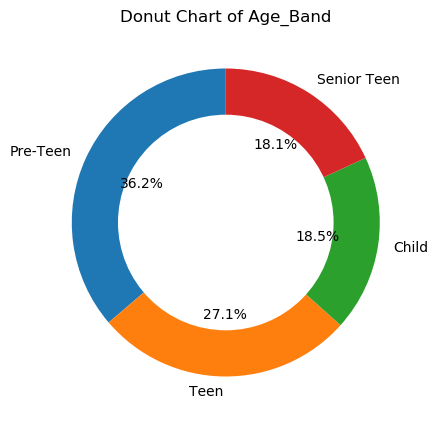

In [23]:
##Categorical values

cat_cols = [
    "Gender",
    "Primary_Device",
    "Exceeded_Recommended_Limit",
    "Urban_or_Rural",
    "Age_Band"
]

for col in cat_cols:
    
    print(f"\nUnivariate Analysis for: {col}")
    
    counts = df[col].value_counts()
    labels = counts.index
    sizes = counts.values
    percentages = (sizes / sizes.sum()) * 100
    
    
    # 1 Count Plot
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()
    
    
    # 2 Pie Chart
    plt.figure(figsize=(5,5))
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90)
    plt.title(f"Pie Chart of {col}")
    plt.show()
    
    
    # 3 Donut Chart
    plt.figure(figsize=(5,5))
    wedges, texts, autotexts = plt.pie(
        sizes, labels=labels, autopct="%1.1f%%", startangle=90
    )
    
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    plt.gca().add_artist(centre_circle)
    
    plt.title(f"Donut Chart of {col}")
    plt.show()


Bivariate Analysis: Age vs Avg_Daily_Screen_Time_hr


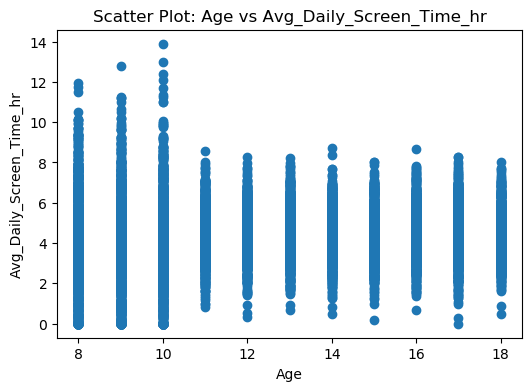

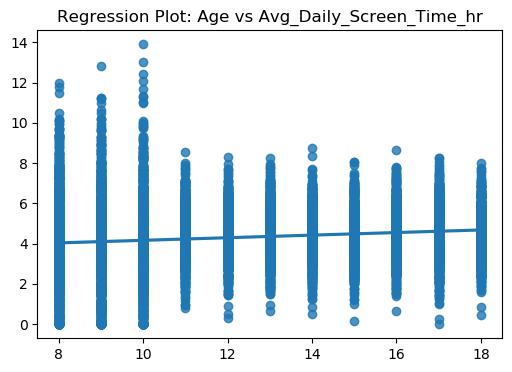

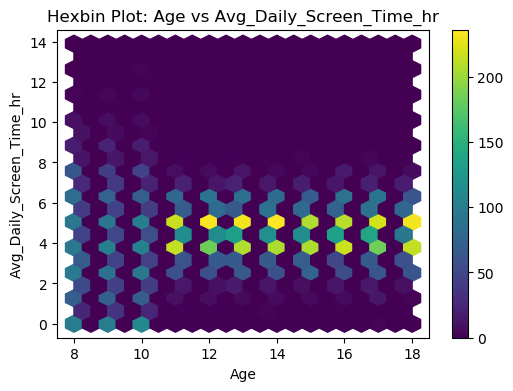


Bivariate Analysis: Age vs Educational_to_Recreational_Ratio


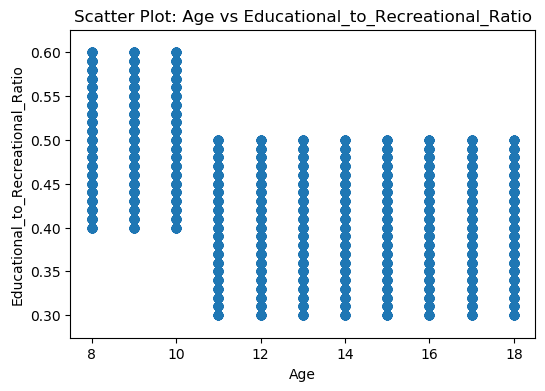

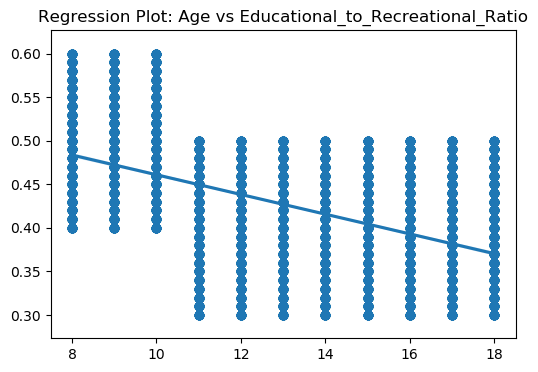

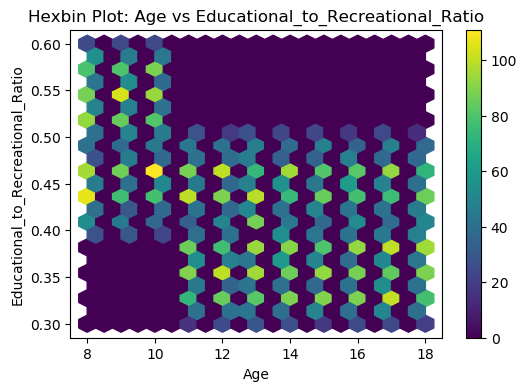


Bivariate Analysis: Age vs Educational_Time_hr


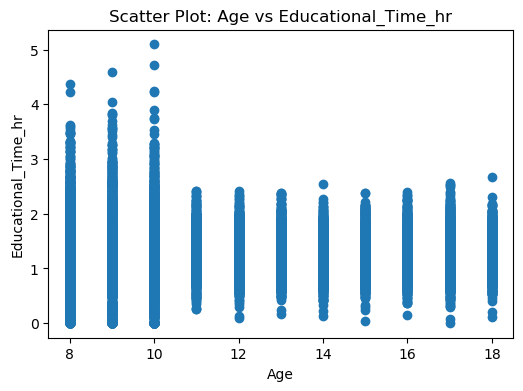

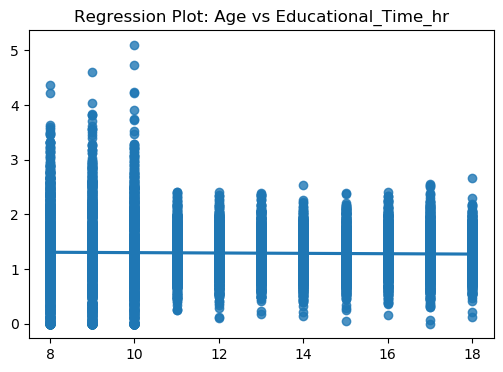

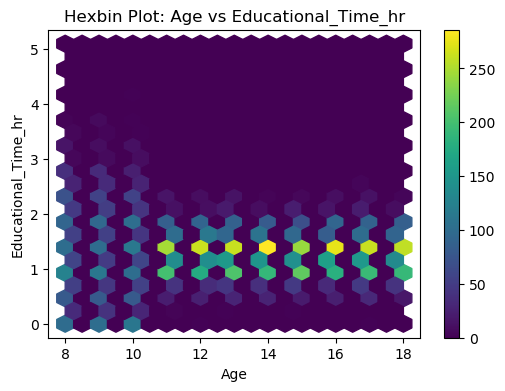


Bivariate Analysis: Age vs Recreational_Time_hr


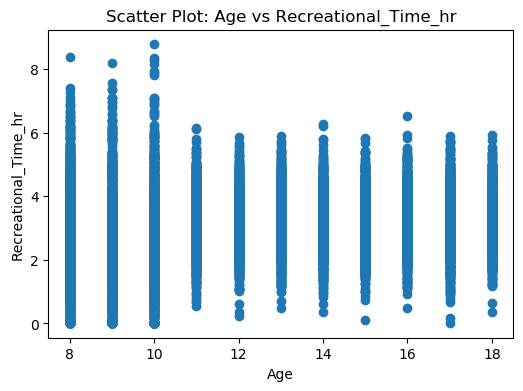

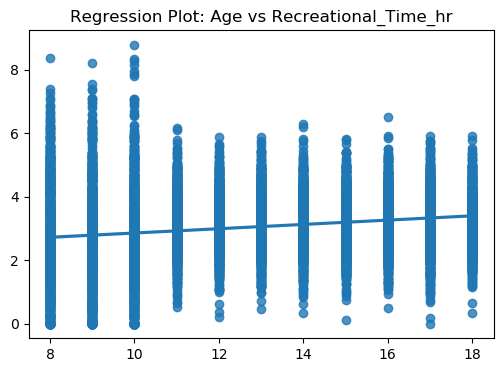

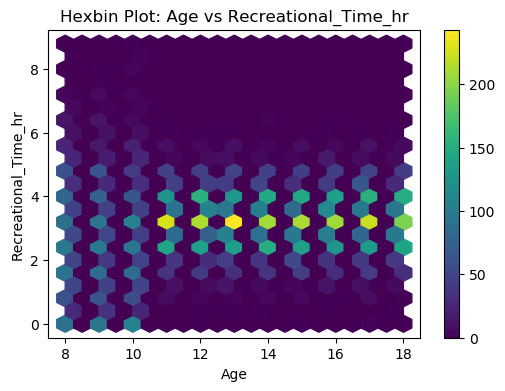


Bivariate Analysis: Avg_Daily_Screen_Time_hr vs Educational_to_Recreational_Ratio


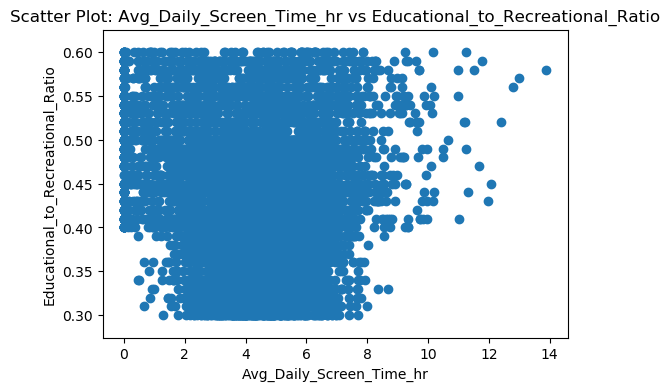

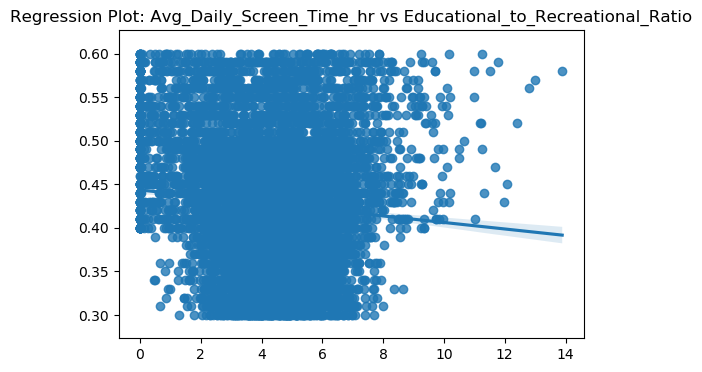

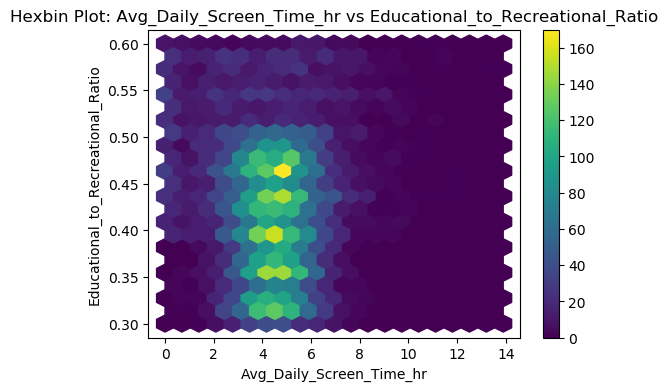


Bivariate Analysis: Avg_Daily_Screen_Time_hr vs Educational_Time_hr


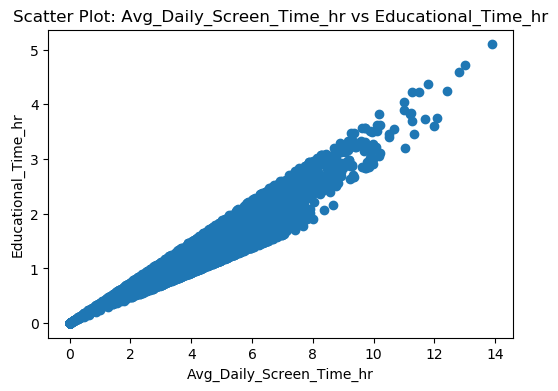

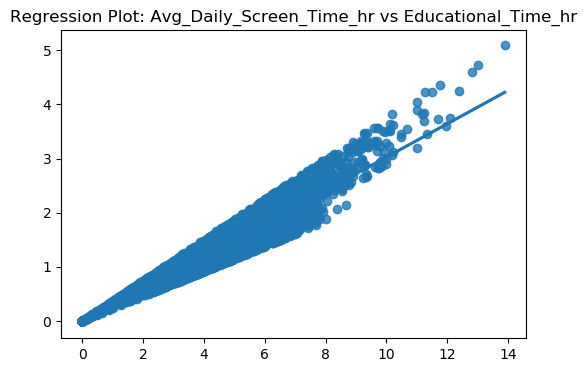

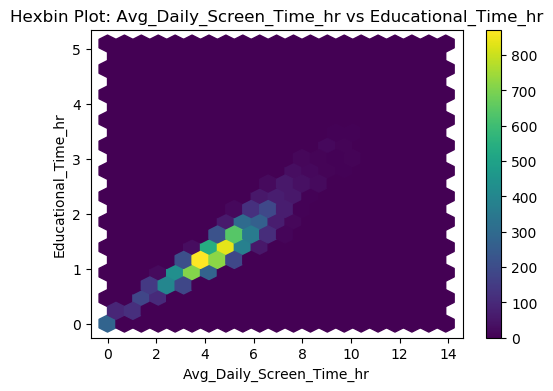


Bivariate Analysis: Avg_Daily_Screen_Time_hr vs Recreational_Time_hr


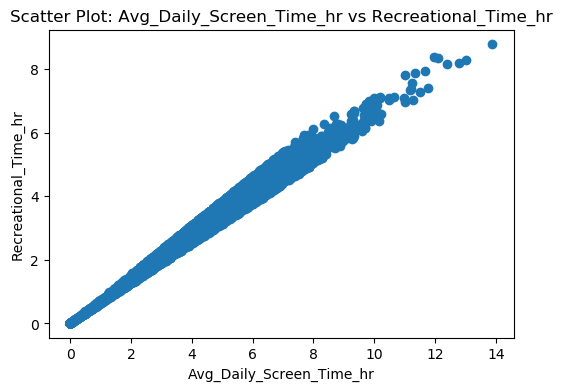

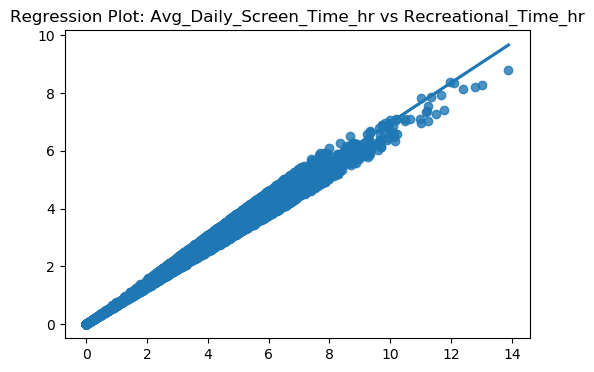

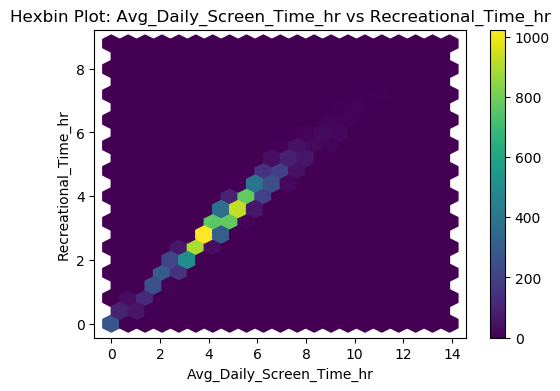


Bivariate Analysis: Educational_to_Recreational_Ratio vs Educational_Time_hr


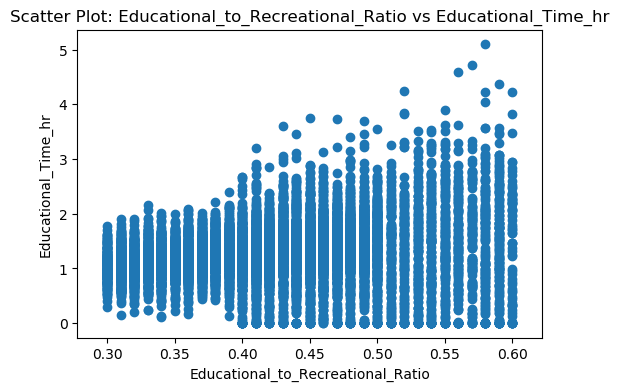

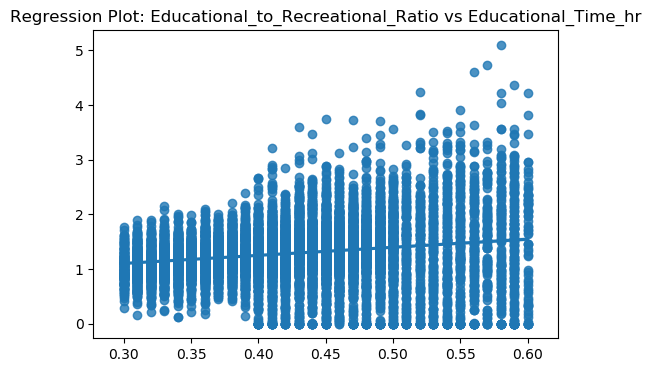

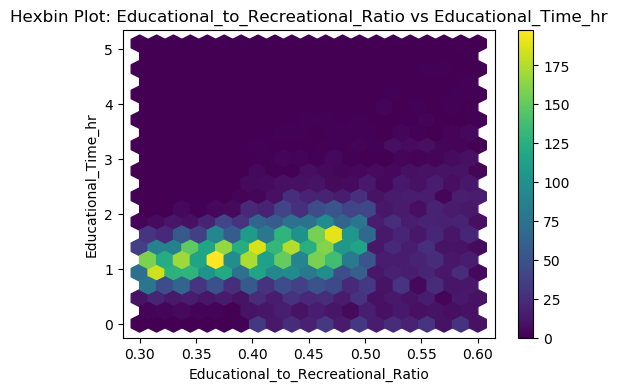


Bivariate Analysis: Educational_to_Recreational_Ratio vs Recreational_Time_hr


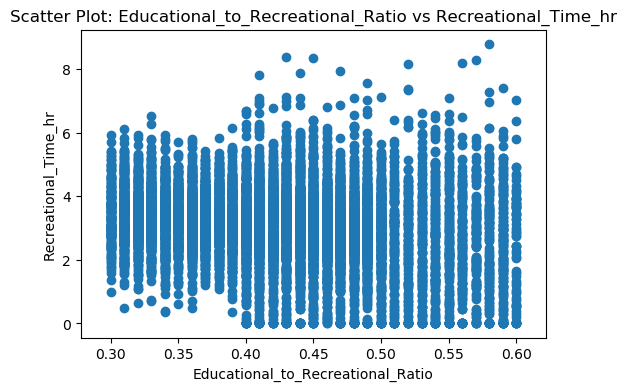

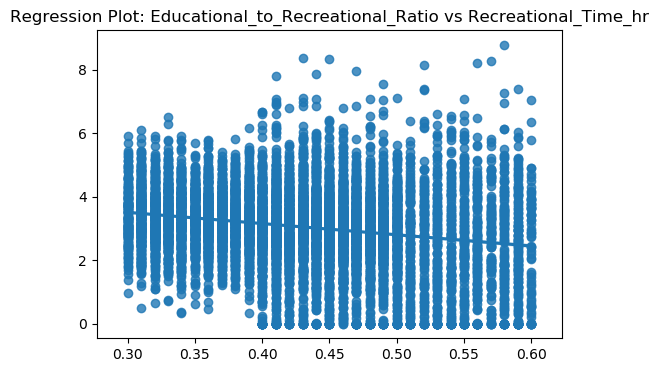

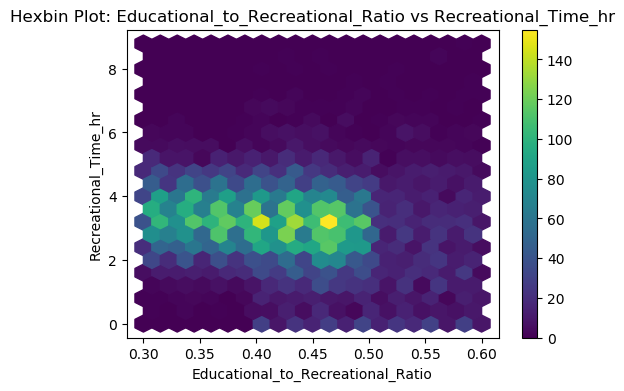


Bivariate Analysis: Educational_Time_hr vs Recreational_Time_hr


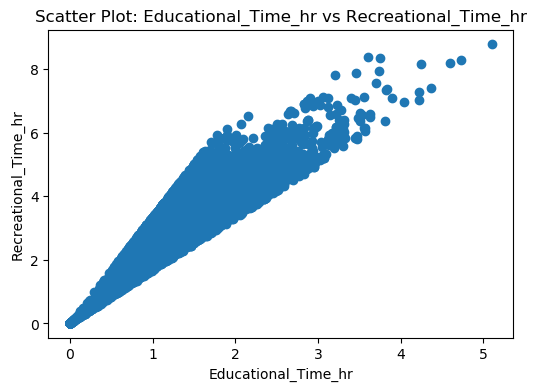

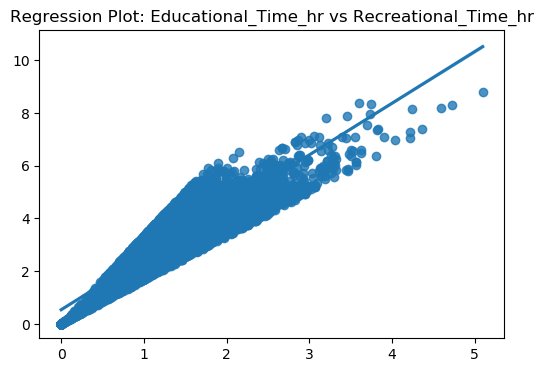

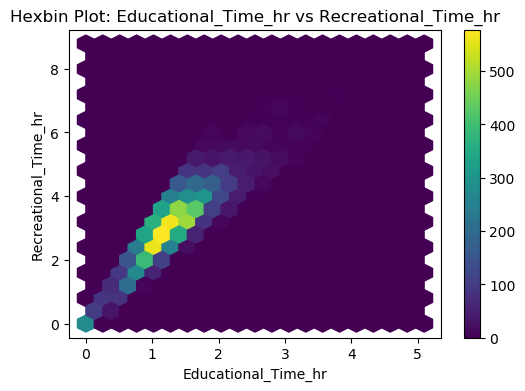

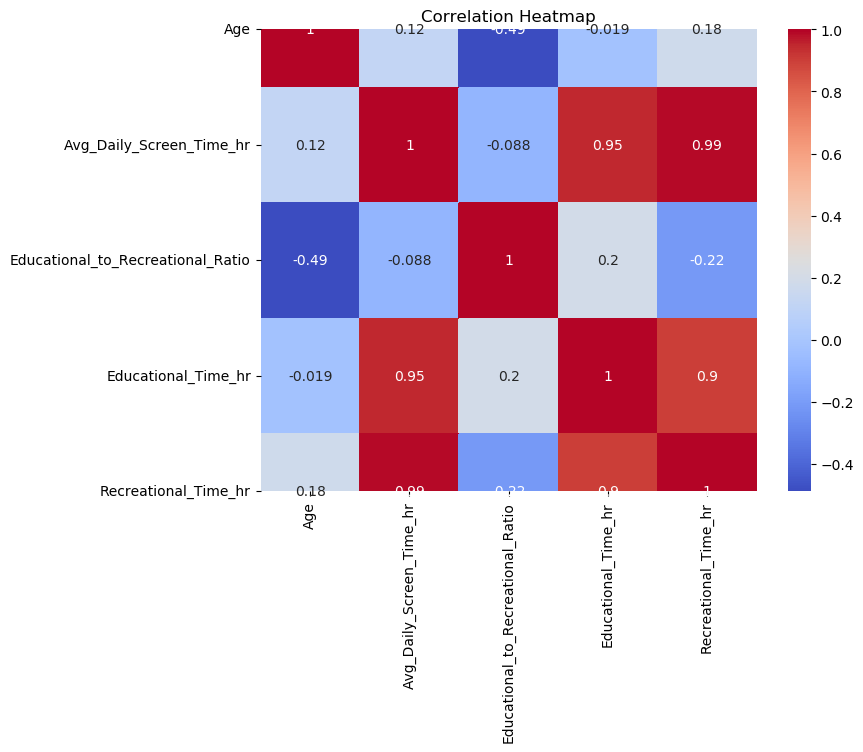

In [26]:
##     BIVARIATE ANALYSIS

##Numerical vs Numerical

import itertools

num_cols = [
    "Age",
    "Avg_Daily_Screen_Time_hr",
    "Educational_to_Recreational_Ratio",
    "Educational_Time_hr",
    "Recreational_Time_hr"
]

pairs = list(itertools.combinations(num_cols, 2))

for x_col, y_col in pairs:
    
    print(f"\nBivariate Analysis: {x_col} vs {y_col}")
    
    x = df[x_col].values
    y = df[y_col].values
    
    # 1 Scatter Plot
    plt.figure(figsize=(6,4))
    plt.scatter(x, y)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Scatter Plot: {x_col} vs {y_col}")
    plt.show()
    
    
    # 2 Regression Plot (SAFE)
    plt.figure(figsize=(6,4))
    sns.regplot(x=x, y=y)
    plt.title(f"Regression Plot: {x_col} vs {y_col}")
    plt.show()
    
    
    # 3 Hexbin Plot
    plt.figure(figsize=(6,4))
    plt.hexbin(x, y, gridsize=20)
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Hexbin Plot: {x_col} vs {y_col}")
    plt.colorbar()
    plt.show()


# 4 Correlation Heatmap (Safe)
plt.figure(figsize=(8,6))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


Bivariate Analysis: Age_Band vs Avg_Daily_Screen_Time_hr


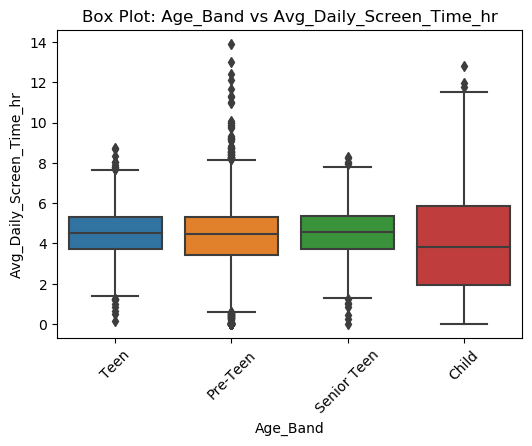

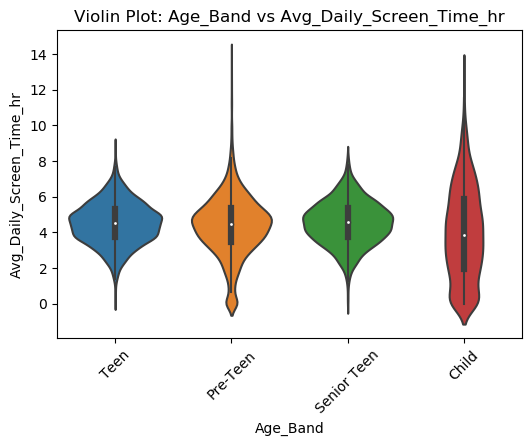

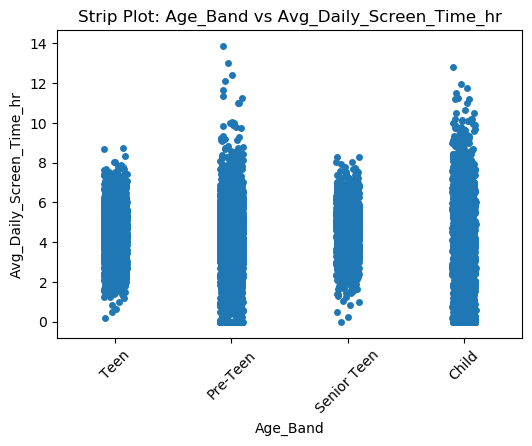

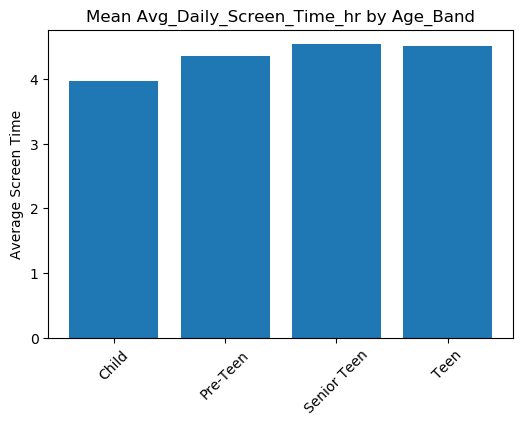


Bivariate Analysis: Gender vs Avg_Daily_Screen_Time_hr


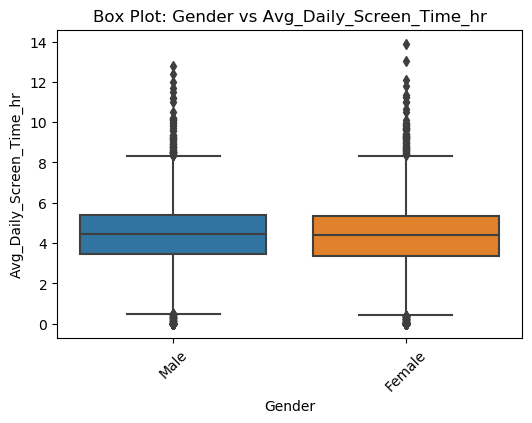

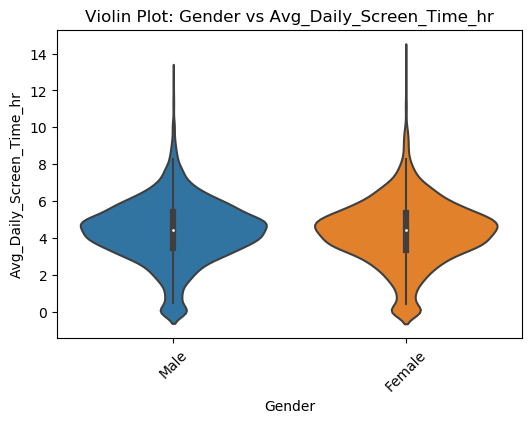

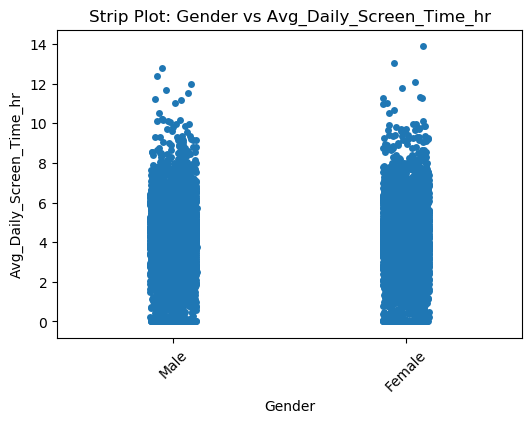

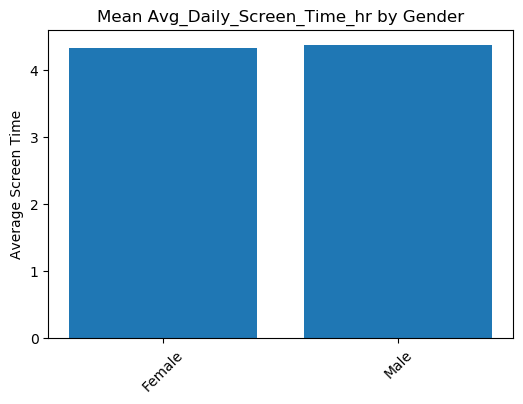


Bivariate Analysis: Urban_or_Rural vs Avg_Daily_Screen_Time_hr


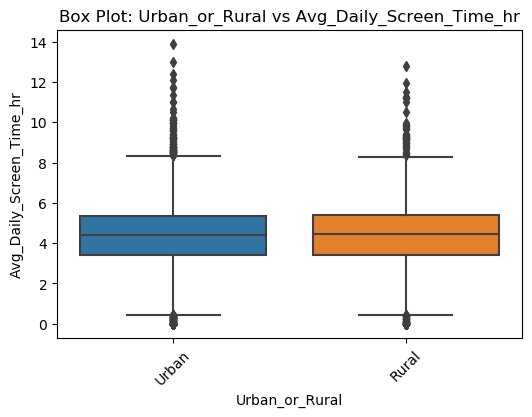

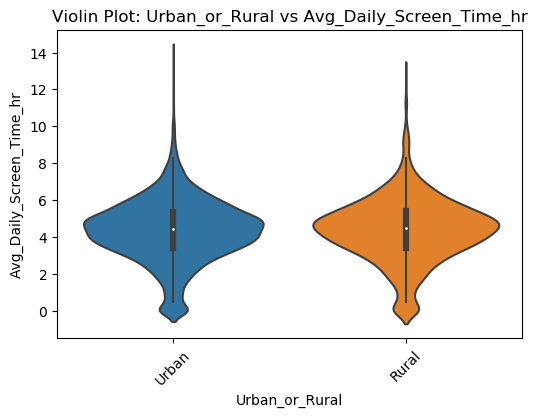

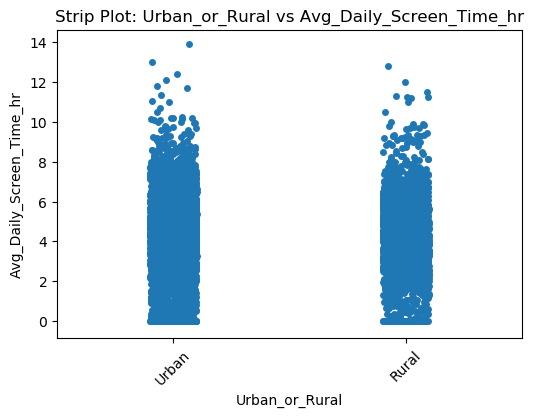

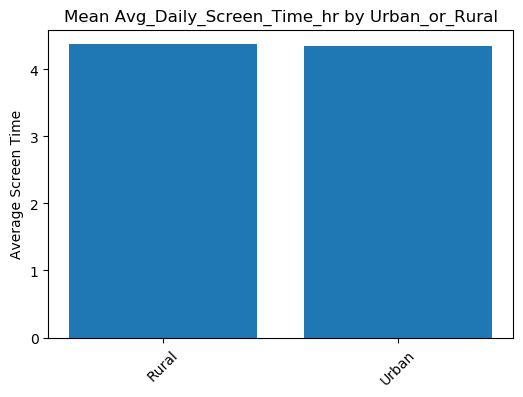


Bivariate Analysis: Exceeded_Recommended_Limit vs Avg_Daily_Screen_Time_hr


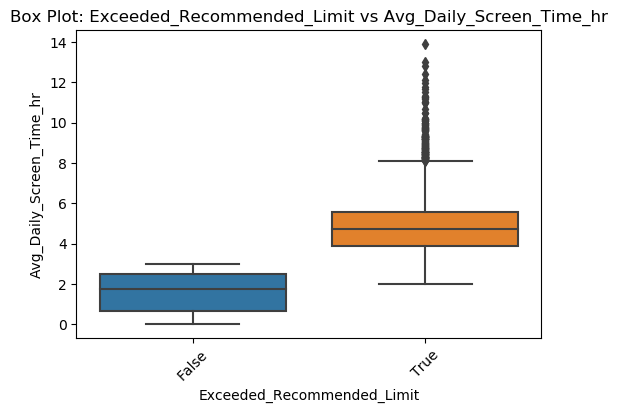

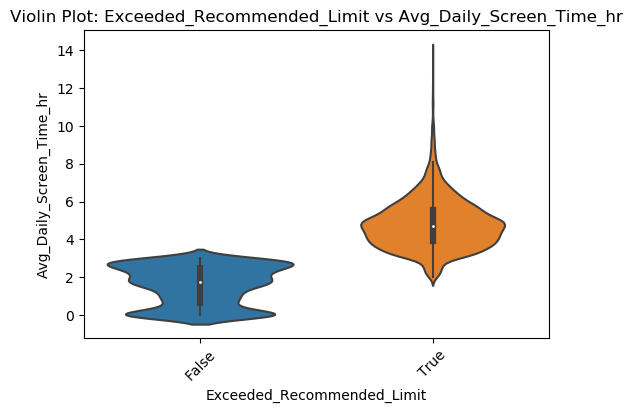

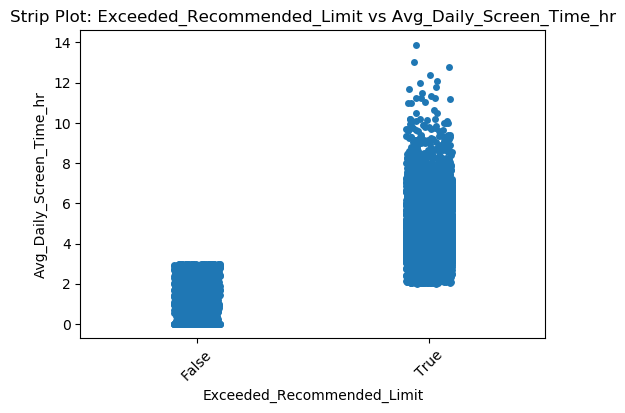

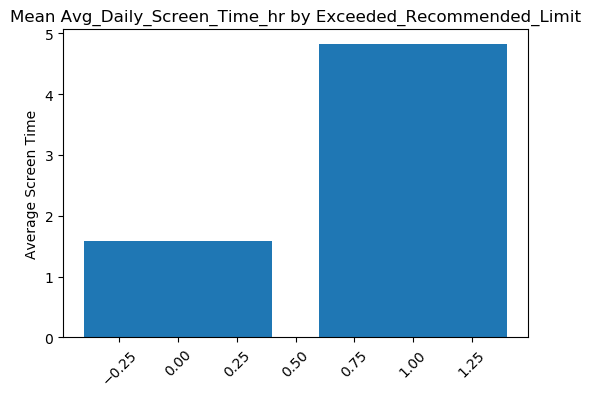


Bivariate Analysis: Primary_Device vs Avg_Daily_Screen_Time_hr


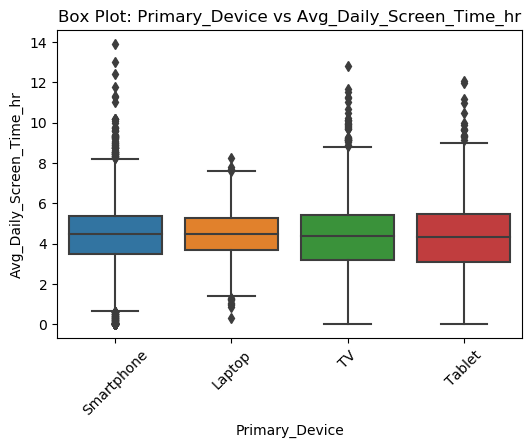

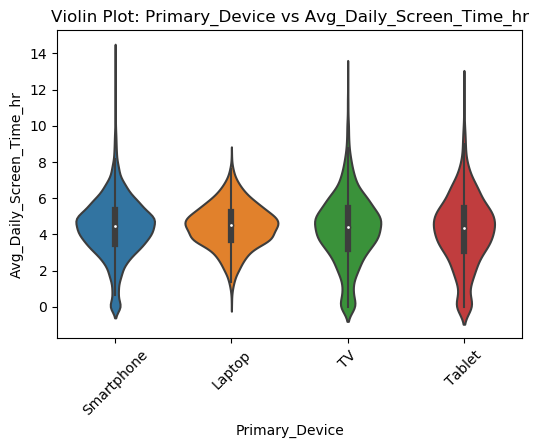

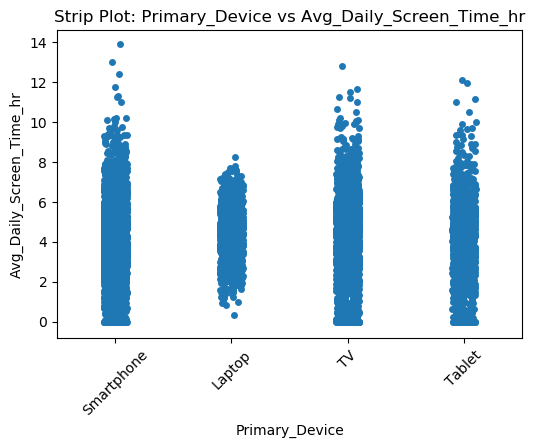

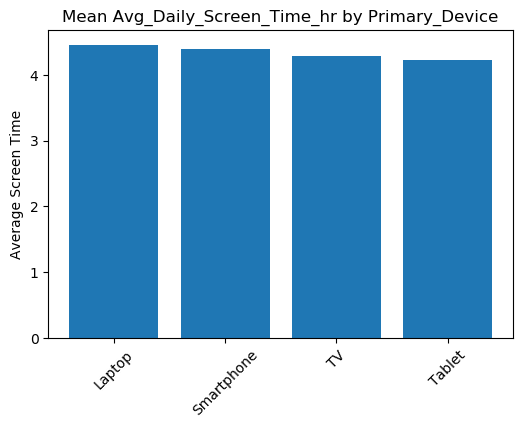

In [27]:
##Numerical vs Categorical

cat_cols = [
    "Age_Band",
    "Gender",
    "Urban_or_Rural",
    "Exceeded_Recommended_Limit",
    "Primary_Device"
]

num_col = "Avg_Daily_Screen_Time_hr"

for col in cat_cols:
    
    print(f"\nBivariate Analysis: {col} vs {num_col}")
    
    # 1 Box Plot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df[num_col])
    plt.title(f"Box Plot: {col} vs {num_col}")
    plt.xticks(rotation=45)
    plt.show()
    
    
    # 2 Violin Plot
    plt.figure(figsize=(6,4))
    sns.violinplot(x=df[col], y=df[num_col])
    plt.title(f"Violin Plot: {col} vs {num_col}")
    plt.xticks(rotation=45)
    plt.show()
    
    
    # 3 Strip Plot
    plt.figure(figsize=(6,4))
    sns.stripplot(x=df[col], y=df[num_col])
    plt.title(f"Strip Plot: {col} vs {num_col}")
    plt.xticks(rotation=45)
    plt.show()
    
    
    # 4 Bar Plot (Mean Comparison)
    plt.figure(figsize=(6,4))
    means = df.groupby(col)[num_col].mean()
    plt.bar(means.index, means.values)
    plt.title(f"Mean {num_col} by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Average Screen Time")
    plt.show()


Bivariate Analysis: Age_Band vs Exceeded_Recommended_Limit


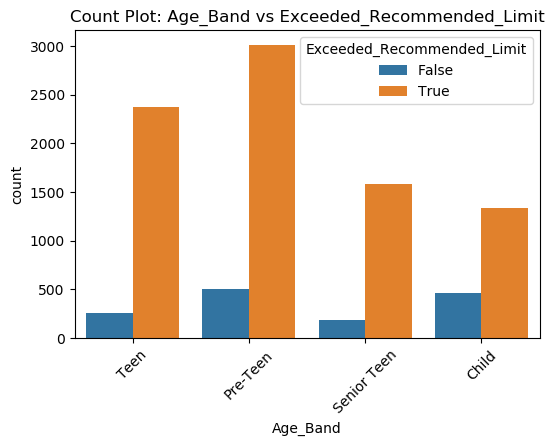

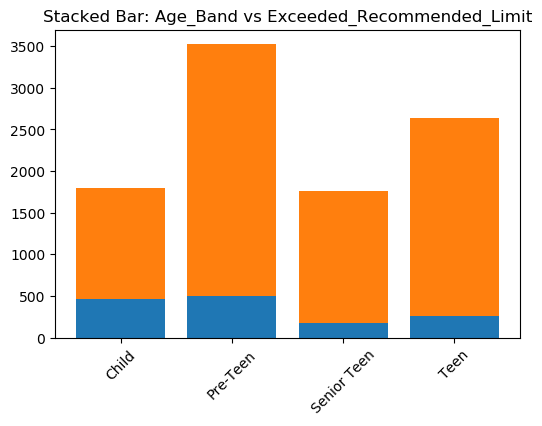

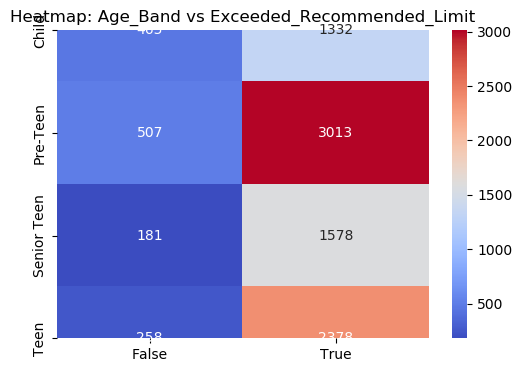


Bivariate Analysis: Gender vs Exceeded_Recommended_Limit


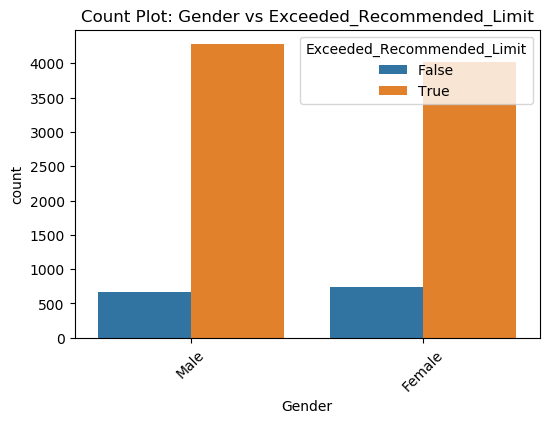

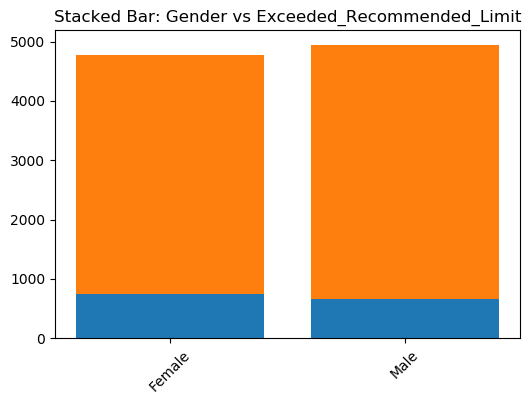

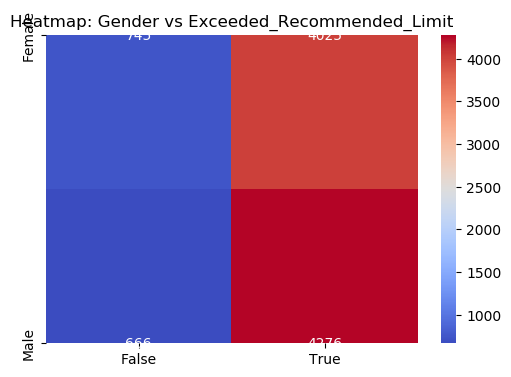


Bivariate Analysis: Urban_or_Rural vs Health_Risk_Level


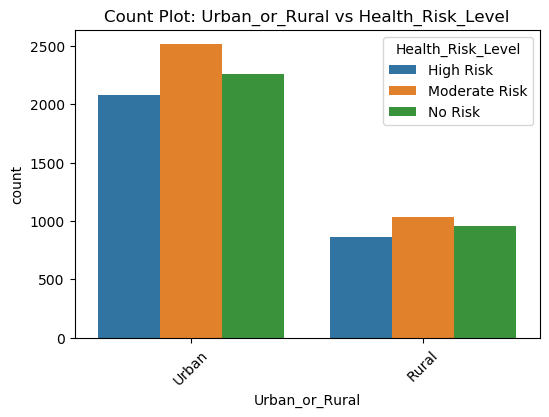

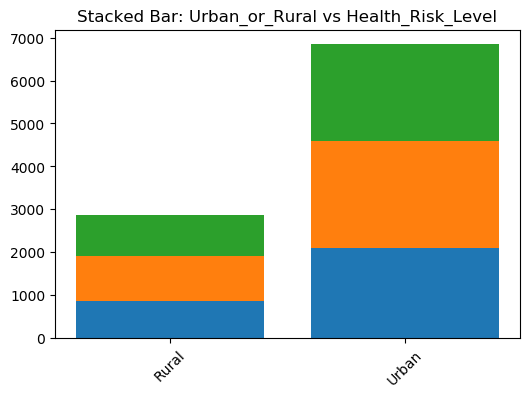

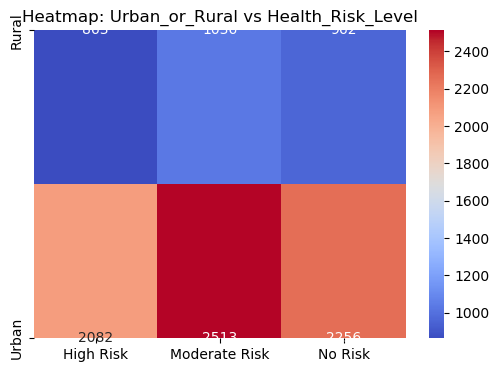


Bivariate Analysis: Primary_Device vs Usage_Balance_Category


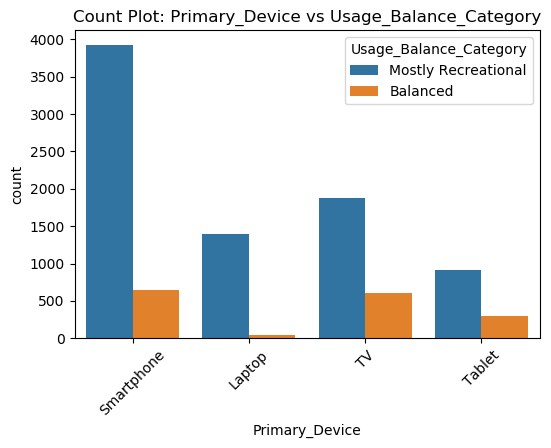

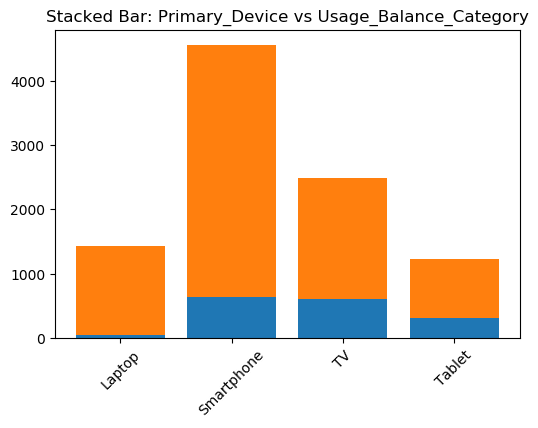

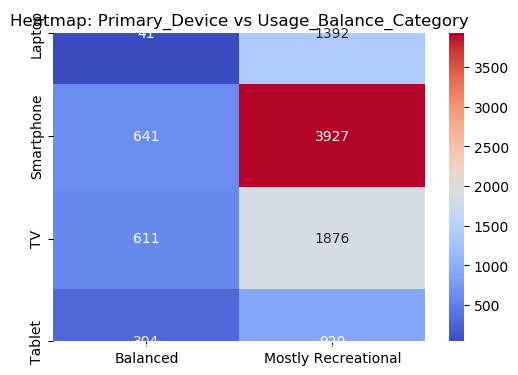


Bivariate Analysis: Age_Band vs Health_Risk_Level


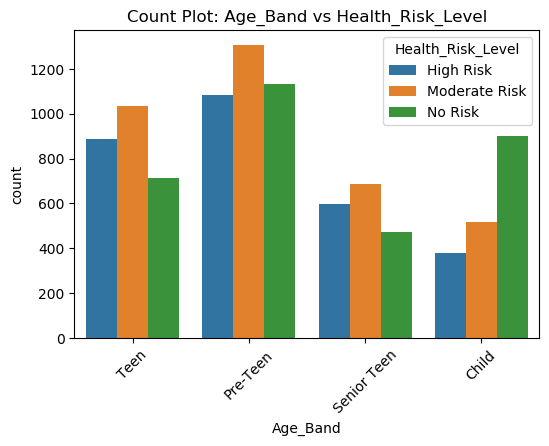

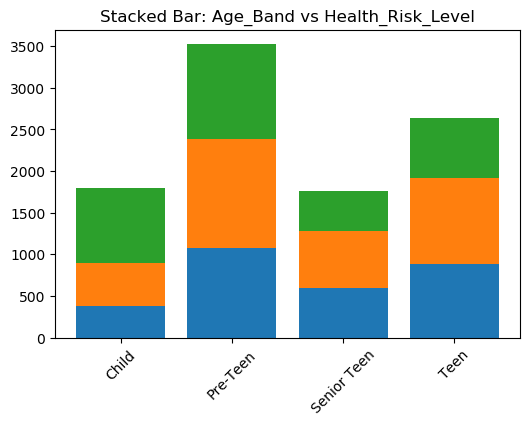

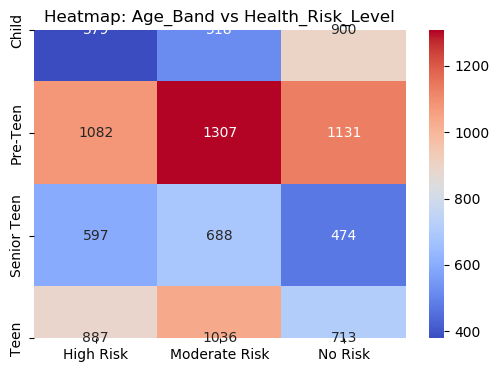

In [30]:
##Categorical vs Categorical

cat_pairs = [
    ("Age_Band", "Exceeded_Recommended_Limit"),
    ("Gender", "Exceeded_Recommended_Limit"),
    ("Urban_or_Rural", "Health_Risk_Level"),
    ("Primary_Device", "Usage_Balance_Category"),
    ("Age_Band", "Health_Risk_Level")
]
for col1, col2 in cat_pairs:
    
    print(f"\nBivariate Analysis: {col1} vs {col2}")
    
    # 1 Countplot with hue
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col1], hue=df[col2])
    plt.title(f"Count Plot: {col1} vs {col2}")
    plt.xticks(rotation=45)
    plt.show()
    
    
    # Create crosstab manually
    cross_tab = pd.crosstab(df[col1], df[col2])
    labels_x = cross_tab.index
    labels_y = cross_tab.columns
    values = cross_tab.values
    
    
    # 2 Stacked Bar Chart (Safe - pure matplotlib)
    plt.figure(figsize=(6,4))
    
    bottom = np.zeros(len(labels_x))
    
    for i in range(len(labels_y)):
        plt.bar(labels_x, values[:, i], bottom=bottom)
        bottom += values[:, i]
    
    plt.title(f"Stacked Bar: {col1} vs {col2}")
    plt.xticks(rotation=45)
    plt.show()
    
    
    # 3 Heatmap (Crosstab)
    plt.figure(figsize=(6,4))
    sns.heatmap(values, annot=True, fmt="d",
                xticklabels=labels_y,
                yticklabels=labels_x,
                cmap="coolwarm")
    plt.title(f"Heatmap: {col1} vs {col2}")
    plt.show()